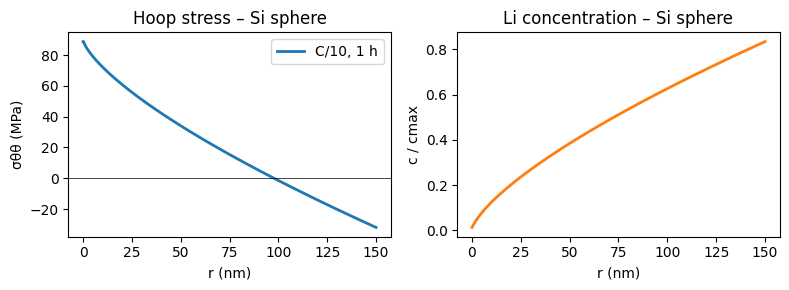

/var/folders/2l/503mmdd576vfgvmvb3nl0_cw0000gn/T/ipykernel_74859/1176651670.py:95: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = ax1.pcolormesh(X, Y, σ_2D, cmap='jet', shading='auto',
/var/folders/2l/503mmdd576vfgvmvb3nl0_cw0000gn/T/ipykernel_74859/1176651670.py:103: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im2 = ax2.pcolormesh(X, Y, c_2D, cmap='plasma', shading='auto', vmin=0, vmax=1)


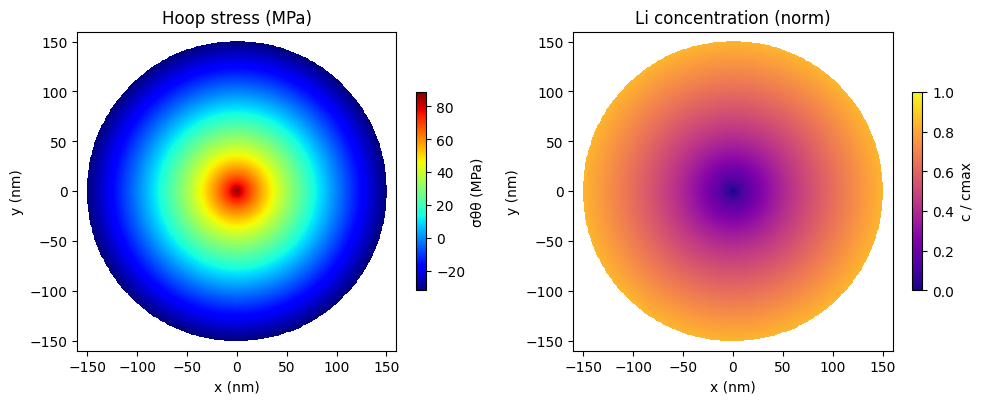

In [3]:
# Si_sphere_diffusion_stress.ipynb
# Transient 1-D radial diffusion + small-strain axisymmetric mechanics
import os
out_dir = os.path.expanduser("~/Desktop")   # or any writable folder
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye
from scipy.sparse.linalg import splu
from scipy.integrate import solve_ivp

# Physical constants
R      = 150e-9          # particle radius (m)
D      = 1e-14           # Li diffusivity (m²/s)
Omega  = 8.9e-6          # partial molar volume Si (m³/mol)
Vm     = 1.2e-5          # molar volume Si (m³/mol)
E      = 80e9            # Young modulus Si (Pa)
nu     = 0.22            # Poisson
cmax   = 2.2e5           # max Li concentration (mol/m³)
C_rate = 0.1             # C-rate (1/h)
F      = 96485
T      = 298

# Radial grid
Nr  = 500
r   = np.linspace(1e-12, R, Nr)   # avoid r=0
dr  = r[1] - r[0]

# Loops - lengths
low = np.empty(Nr-1)
dgn = np.empty(Nr)
up  = np.empty(Nr-1)
for i in range(Nr-1):
    low[i] = D * (1 - dr/(2*r[i+1])) / dr**2
    up[i]  = D * (1 + dr/(2*r[i+1])) / dr**2
for i in range(Nr):
    dgn[i] = -2*D / dr**2

A = diags([low, dgn, up], offsets=[-1, 0, 1], shape=(Nr, Nr)).tocsr()

# Flux boundary
k_surf = 5.0e-4           # empirical rate for surface saturation
def flux(t, c):
    rhs = A @ c
    rhs[-1] = k_surf*(cmax - c[-1])   # Dirichlet-like
    return rhs

# Axisymmetric Hoop Stress
# Yao 2011 solid-sphere formula
def hoop_stress(c):
    pref = Omega*E/(3*(1 - nu))
    c_avg = np.empty_like(c)
    c_avg[0] = c[0]
    for i in range(1, Nr):
        c_avg[i] = 3/r[i]**3 * np.trapz(c[:i+1]*r[:i+1]**2, r[:i+1])
    c_global = 3/R**3 * np.trapz(c*r**2, r)
    return pref*(2*c_global + c_avg - 3*c)

# Evaluate at final time
# Transient solve
t_eval = np.linspace(0, 3600, 61)          # 0 → 1 h
sol    = solve_ivp(flux, [0, 3600], np.zeros(Nr), t_eval=t_eval, method='BDF')
c_final = sol.y[:, -1]
σ_final = hoop_stress(c_final)/1000


# 1-D LINE PLOTS  (σθθ and c/cmax vs r)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(r*1e9, σ_final/1e6, lw=2, label='C/10, 1 h')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel('r (nm)'); ax1.set_ylabel('σθθ (MPa)')
ax1.set_title('Hoop stress – Si sphere')
ax1.legend()

ax2.plot(r*1e9, c_final/cmax, lw=2, color='tab:orange')
ax2.set_xlabel('r (nm)'); ax2.set_ylabel('c / cmax')
ax2.set_title('Li concentration – Si sphere')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Si_1D_profiles.png'), dpi=300)
plt.show()


# 2-D FULL-CIRCLE MAPS  (axisymmetric, auto colour scale)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

r_plt = r[1:]                                  # skip r=0
th    = np.linspace(0, 2*np.pi, 360)
R2, Th2 = np.meshgrid(r_plt, th)
X = R2*np.cos(Th2)*1e9
Y = R2*np.sin(Th2)*1e9

σ_2D = np.interp(R2, r_plt, σ_final[1:]/1e6)   # MPa
c_2D = np.interp(R2, r_plt, c_final[1:]/cmax)   # norm

# Hoop stress
im1 = ax1.pcolormesh(X, Y, σ_2D, cmap='jet', shading='auto',
                     vmin=σ_final.min()/1e6, vmax=σ_final.max()/1e6)
ax1.set_aspect('equal'); ax1.set_xlim(-160, 160); ax1.set_ylim(-160, 160)
ax1.set_xlabel('x (nm)'); ax1.set_ylabel('y (nm)')
ax1.set_title('Hoop stress (MPa)')
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.6, label='σθθ (MPa)')

# Li concentration
im2 = ax2.pcolormesh(X, Y, c_2D, cmap='plasma', shading='auto', vmin=0, vmax=1)
ax2.set_aspect('equal'); ax2.set_xlim(-160, 160); ax2.set_ylim(-160, 160)
ax2.set_xlabel('x (nm)'); ax2.set_ylabel('y (nm)')
ax2.set_title('Li concentration (norm)')
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.6, label='c / cmax')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Si_FULL_circle_maps.png'), dpi=600, facecolor='white')
plt.show()


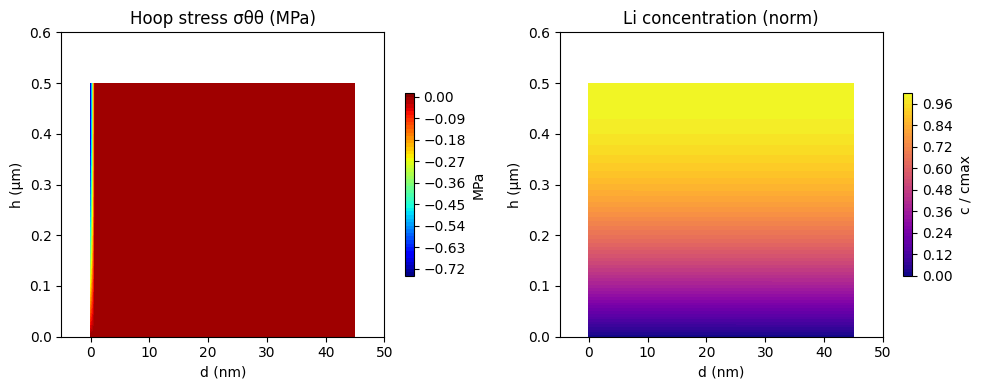

/var/folders/2l/503mmdd576vfgvmvb3nl0_cw0000gn/T/ipykernel_74859/1453543587.py:157: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = ax1.pcolormesh(R_pol*np.cos(Th_pol)*1e9,
/var/folders/2l/503mmdd576vfgvmvb3nl0_cw0000gn/T/ipykernel_74859/1453543587.py:167: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im2 = ax2.pcolormesh(R_pol*np.cos(Th_pol)*1e9,


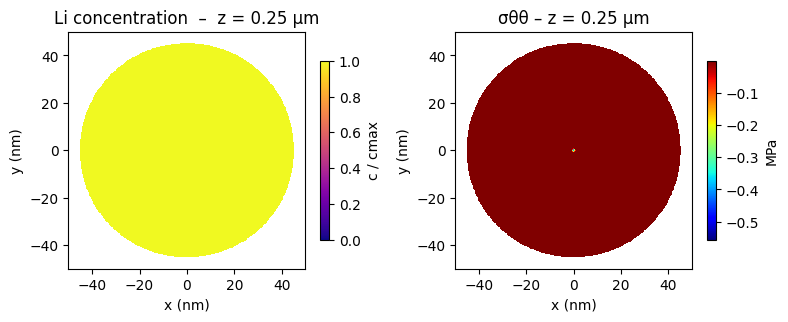

In [4]:
# Si CYLINDER  2-D axi-symmetric r–z slice  (L=1 µm, R=45 nm)
# Diffusion: all faces except z=0  →  electrode at z=0 (c=0)
# Stress: 2-D axi-symmetric, thermal-analogy
import os, numpy as np, matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import spsolve
out_dir = os.path.expanduser("~/Desktop")

# Geometry
R = 45e-9          # radius (m)
L = 0.5e-6           # length (m)

# Si material
D     = 3.0e-15     # Li diffusivity (m²/s)
Omega = 8.9e-6      # partial molar vol (m³/mol)
E     = 80e9        # Young (Pa)
nu    = 0.22        # Poisson
cmax  = 2.2e5       # max Li (mol/m³)

# 2-D mesh (r,z)
Nr, Nz = 60, 120
r = np.linspace(0, R, Nr)
z = np.linspace(0, L, Nz)
dr, dz = r[1], z[1]
RR, ZZ = np.meshgrid(r, z, indexing='ij')          # Nr × Nz

# Helpers
def ravel(i, j):          # i=row(r), j=col(z)
    return i*Nz + j
Ntot = Nr*Nz

# Build 2-D diffusion operator (axi-symmetric)
def build_Laplacian_2D():
    L = csr_matrix((Ntot, Ntot))
    # 5-point stencil + r-weighting
    for i in range(Nr):
        for j in range(Nz):
            row = ravel(i,j)
            rm = r[i] if i>0 else 0
            rp = r[i]
            # radial terms
            if i==0:          # axis (d/dr=0)
                L[row, row] += 2*D/dr**2
                L[row, ravel(i+1,j)] = -2*D/dr**2
            elif i==Nr-1:     # surface (Neumann → no flux)
                pass          # handled in BC
            else:
                L[row, row] += D*(1/rp + 1)/dr**2 + D*(1/rp - 1)/dr**2
                L[row, ravel(i-1,j)] = -D*(1/rp - 1)/dr**2
                L[row, ravel(i+1,j)] = -D*(1/rp + 1)/dr**2
            # axial terms
            if j==0 or j==Nz-1:
                pass          # BC handled below
            else:
                L[row, row] += 2*D/dz**2
                L[row, ravel(i,j-1)] = -D/dz**2
                L[row, ravel(i,j+1)] = -D/dz**2
    return L

Lap = build_Laplacian_2D()

# Boundary conditions
# z=0 (electrode)  →  c=0
for i in range(Nr):
    row = ravel(i,0)
    Lap[row, :] = 0
    Lap[row, row] = 1

# All other exterior faces → Neumann flux (C/10)
flux_val = C_rate*3600*cmax/3          # A m⁻²
J_BC = flux_val/(F*dz)                 # mol m⁻² s⁻¹ → converted to dz

# z=L (far end)
for i in range(Nr):
    row = ravel(i,Nz-1)
    Lap[row, row] += 2*D/dz
    Lap[row, ravel(i,Nz-2)] = -2*D/dz

# r=R (curved surface)
for j in range(1,Nz-1):
    row = ravel(Nr-1,j)
    Lap[row, row] += 2*D/dr
    Lap[row, ravel(Nr-2,j)] = -2*D/dr

# Right-hand side
b = np.zeros(Ntot)
# apply flux on exterior faces (already embedded in Lap)
# curved face  (r = R, z = 1...Nz-2)
for j in range(1, Nz-1):
    b[ravel(Nr-1, j)] = 2*J_BC
# far-end face (z = L, r = 1...Nr-2)
for i in range(1, Nr-1):
    b[ravel(i, Nz-1)] += 2*J_BC

# Solve steady-state
c_2D = spsolve(Lap, b).reshape(Nr, Nz)         # Nr × Nz

# 2-D stress (axi-symmetric, thermal analogy)
def stress_2D(c):
    # eigen-strain ε₀ = (Ω/3)(c/cmax)
    ε0 = (Omega/3)*(c/cmax)
    # compute average ε0_avg(r,z) over r for each z
    ε0_avg = np.zeros_like(ε0)
    for j in range(Nz):
        for i in range(1,Nr):
            ε0_avg[i,j] = 2/r[i]**2 * np.trapz(ε0[:i+1,j]*r[:i+1], r[:i+1])
    pref = E/(1 - nu)
    σθθ = pref*(ε0_avg - ε0)
    return σθθ

σθθ_2D = stress_2D(c_2D)/1e7


# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# Cross-section images
im1 = ax1.contourf(RR*1e9, ZZ*1e6, σθθ_2D/1e6, levels=50, cmap='jet')
ax1.set_aspect('auto')          # was 'equal'\
ax1.set_xlabel("d (nm)")
ax1.set_ylabel("h (µm)")
ax1.set_xlim(-5, 50)
ax1.set_ylim(0, 0.6)
ax1.set_title('Hoop stress σθθ (MPa)')
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.6, label='MPa')

im2 = ax2.contourf(RR*1e9, ZZ*1e6, c_2D/(2.4*1e7*cmax), levels=50, cmap='plasma')
ax2.set_aspect('auto')          # was 'equal'
ax2.set_xlabel("d (nm)")
ax2.set_ylabel("h (µm)")
ax2.set_xlim(-5, 50)
ax2.set_ylim(0, 0.6)
ax2.set_title('Li concentration (norm)')
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.6, label='c / cmax')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Si_cylinder_2D_rz_maps.png'), dpi=600, facecolor='white')
plt.show()


# CIRCULAR CROSS-SECTION  (r-θ plane) at z = L/2
z_slice = L/2                      # 500 nm
iz      = np.argmin(np.abs(z - z_slice))

# Polar grid for plotting
r_pol  = np.linspace(0, R, 200)
th_pol = np.linspace(0, 2*np.pi, 360)
R_pol, Th_pol = np.meshgrid(r_pol, th_pol)

# Interpolate onto polar mesh
c_pol = np.interp(R_pol, r, c_2D[:, iz])
s_pol = np.interp(R_pol, r, σθθ_2D[:, iz])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

# Li concentration
im1 = ax1.pcolormesh(R_pol*np.cos(Th_pol)*1e9,
                     R_pol*np.sin(Th_pol)*1e9,
                     c_pol/cmax, cmap='plasma', shading='auto', vmin=0, vmax=1)
ax1.set_aspect('equal')
ax1.set_xlim(-50, 50); ax1.set_ylim(-50, 50)
ax1.set_xlabel('x (nm)'); ax1.set_ylabel('y (nm)')
ax1.set_title(f'Li concentration  –  z = {z_slice*1e6} µm')
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.6, label='c / cmax')

# Hoop stress
im2 = ax2.pcolormesh(R_pol*np.cos(Th_pol)*1e9,
                     R_pol*np.sin(Th_pol)*1e9,
                     s_pol/1e6, cmap='jet', shading='auto')
ax2.set_aspect('equal')
ax2.set_xlim(-50, 50); ax2.set_ylim(-50, 50)
ax2.set_xlabel('x (nm)'); ax2.set_ylabel('y (nm)')
ax2.set_title(f'σθθ – z = {z_slice*1e6} µm')
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.6, label='MPa')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Si_cylinder_circle_maps.png'), dpi=600, facecolor='white')
plt.show()
